In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from natsort import natsorted
import matplotlib as mpl

# Add function path
original_path = os.getcwd()
os.chdir(original_path)
function_path = './functions/'
sys.path.append(function_path)

# Import custom functions
from analysis_function import *
from kcc_constrain_function import *
from Plot_function import *
from f1_0_H_sum_multi_region_constrain import *
from f_IMP import *
from f_schemes import *
from ar6_area_weighted_cont_global import *


In [3]:
path = './saved_data/'

def load_xr_pickle(filename):
    with open(filename, "rb") as f:
        return pickle.load(f)

obs_all = load_xr_pickle(path + '0.1.HadCRUT5.Tas.anomalies.46AR6regions_7cont_1glob_175years_1850-2024.pkl')

obs_200runs_all = load_xr_pickle(path + '0.2.HadCRUT5.200runs.nonmasked.Tas.anomalies.46AR6regions_7cont_1glob_175years_1850-2024.pkl')

mod_all = load_xr_pickle(path + '0.4.Smoothed_His-ALL.25mods.mean.nonmasked.Tas.anomalies.46AR6regions_7cont_1glob_171years_1850-2020.pkl')

mod_sub_forcing = load_xr_pickle(path + '0.4.Smoothed_His-ANT.NAT.GHG.OA.10mods.mean.nonmasked.Tas.anomalies.46AR6regions_7cont_1glob_171years_1850-2020.pkl')

mod_all = xr.concat([mod_all,mod_sub_forcing],dim = 'forcing')

ln_mod_all = load_xr_pickle(path + '0.3.Large_ensembles.320runs.nonmasked.Tas.anomalies.46AR6regions_7cont_1glob_251years_1850-2100.pkl')

mod_45_pseudo = load_xr_pickle(path + '0.5.pseudo-model.15mod.run1-3.nonmasked.Tas.anomalies.46AR6regions_7cont_1glob_176years_1850-2025.pkl')

print_xarray_info(obs_all, obs_200runs_all, mod_all, ln_mod_all, mod_45_pseudo)


Array 1:
  Sizes: Frozen({'year': 175, 'region': 54})
  Coords: ['realization', 'year', 'region', 'abbrevs', 'names']

Array 2:
  Sizes: Frozen({'runs': 200, 'year': 175, 'region': 54})
  Coords: ['runs', 'year', 'region', 'abbrevs', 'names']

Array 3:
  Sizes: Frozen({'forcing': 5, 'model_name': 25, 'year': 176, 'region': 54})
  Coords: ['model_name', 'region', 'year', 'forcing', 'abbrevs', 'names']

Array 4:
  Sizes: Frozen({'model_run': 320, 'year': 251, 'region': 54})
  Coords: ['year', 'model_run', 'model_name', 'region', 'abbrevs', 'names']

Array 5:
  Sizes: Frozen({'model_run': 45, 'year': 176, 'region': 54})
  Coords: ['model_run', 'year', 'model_name', 'region', 'abbrevs', 'names']


In [4]:
np.unique(ln_mod_all['model_name'].values)

array(['ACCESS-ESM1-5', 'CESM2', 'CanESM5', 'MIROC-ES2L', 'MIROC6',
       'MPI-ESM1-2-LR'], dtype='<U13')

In [5]:
from f_schemes import *

# -----------------------------------------
# Define time periods
# -----------------------------------------

ref_period = (1850, 1900)

warming_target_period1 = (2016, 2025)

# -----------------------------------------
# Define constraint schemes
# -----------------------------------------
region_groups = {
    'North and Central America': ['GIC', 'NWN', 'NEN', 'WNA', 'CNA', 'ENA', 'NCA', 'SCA', 'CAR'],
    'South America': ['NWS', 'NSA', 'NES', 'SAM', 'SWS', 'SES', 'SSA'],
    'Europe': ['NEU', 'WCE', 'EEU', 'MED'],
    'Africa': ['SAH', 'WAF', 'CAF', 'NEAF', 'SEAF', 'WSAF', 'ESAF', 'MDG'],
    'Asia': ['RAR', 'WSB', 'ESB', 'RFE', 'WCA', 'ECA', 'TIB', 'EAS', 'ARP', 'SAS'],
    'Australasia': ['SEA', 'NAU', 'CAU', 'EAU', 'SAU', 'NZ'],
    'Antarctica': ['EAN', 'WAN'],
    'Global land': ['LSAT']
}

scheme_reg_lsat = generate_global_regional_target_constraint_pairs(region_groups, global_abbrev='LSAT')

scheme_reg_lsat

[{'target_reg': 'GIC', 'constrain_used_reg': ['GIC', 'LSAT']},
 {'target_reg': 'NWN', 'constrain_used_reg': ['NWN', 'LSAT']},
 {'target_reg': 'NEN', 'constrain_used_reg': ['NEN', 'LSAT']},
 {'target_reg': 'WNA', 'constrain_used_reg': ['WNA', 'LSAT']},
 {'target_reg': 'CNA', 'constrain_used_reg': ['CNA', 'LSAT']},
 {'target_reg': 'ENA', 'constrain_used_reg': ['ENA', 'LSAT']},
 {'target_reg': 'NCA', 'constrain_used_reg': ['NCA', 'LSAT']},
 {'target_reg': 'SCA', 'constrain_used_reg': ['SCA', 'LSAT']},
 {'target_reg': 'CAR', 'constrain_used_reg': ['CAR', 'LSAT']},
 {'target_reg': 'NWS', 'constrain_used_reg': ['NWS', 'LSAT']},
 {'target_reg': 'NSA', 'constrain_used_reg': ['NSA', 'LSAT']},
 {'target_reg': 'NES', 'constrain_used_reg': ['NES', 'LSAT']},
 {'target_reg': 'SAM', 'constrain_used_reg': ['SAM', 'LSAT']},
 {'target_reg': 'SWS', 'constrain_used_reg': ['SWS', 'LSAT']},
 {'target_reg': 'SES', 'constrain_used_reg': ['SES', 'LSAT']},
 {'target_reg': 'SSA', 'constrain_used_reg': ['SSA', 'L

In [6]:
#### global_region constraint
mod_all_new = xr.concat([mod_all.isel(region=slice(0, 46)), mod_all.isel(region=53)], dim = 'region')


constrain_func = constrain_sum_reg
obs = obs_all
obs_200runs = obs_200runs_all
ln_mod = ln_mod_all
mod_his = mod_all_new


mod_da = mod_all_new
obs_ar6 = obs_all
region_names = list(mod_da.names.values)
forcing_list = mod_da.forcing  # xarray.DataArray
his_forcing = ['ALL']
constrain_forcing_names=['ALL']

scheme_pairs =  scheme_reg_lsat

prior_warm_ALL, post_warm_ALL, prior_smooth_ALL, post_smooth_ALL, obs_adj_ALL = \
    process_all_regions(scheme_pairs, constrain_func, obs, obs_200runs, ln_mod, mod_his, mod_da, obs_ar6, region_names, forcing_list, his_forcing, constrain_forcing_names, reg_id = slice(0, len(region_names)), calc_smoothed = True, print_constraint_regions = True)


Processing region 0: Greenland/Iceland
 Constraining used region 0: ['GIC', 'LSAT']
Processing region 1: N.W.North-America
 Constraining used region 1: ['NWN', 'LSAT']
Processing region 2: N.E.North-America
 Constraining used region 2: ['NEN', 'LSAT']


KeyboardInterrupt: 

### ALL = ANT + NAT, to constrain ANT and NAT

In [11]:
#### lsat_region constraint
constrain_func = constrain_sum_reg
obs = obs_all
obs_200runs = obs_200runs_all
ln_mod = ln_mod_all
mod_his = mod_all_new
mod_da = mod_all_new
obs_ar6 = obs_all
region_names = list(mod_da.names.values)
forcing_list = mod_da.forcing  # xarray.DataArray
his_forcing = ['ANT', 'NAT']
constrain_forcing_names=['ANT', 'NAT']

prior_warm_ANT_NAT, post_warm_ANT_NAT, prior_smooth_ANT_NAT, post_smooth_ANT_NAT, obs_adj_ANT_NAT = \
    process_all_regions(scheme_pairs, constrain_func, obs, obs_200runs, ln_mod, mod_his, mod_da, obs_ar6, region_names, forcing_list, his_forcing, constrain_forcing_names, reg_id = slice(0, len(region_names)), calc_smoothed = True, print_constraint_regions = True)



Processing region 0: Greenland/Iceland
 Constraining used region 0: ['GIC', 'LSAT']
Processing region 1: N.W.North-America
 Constraining used region 1: ['NWN', 'LSAT']
Processing region 2: N.E.North-America
 Constraining used region 2: ['NEN', 'LSAT']
Processing region 3: W.North-America
 Constraining used region 3: ['WNA', 'LSAT']
Processing region 4: C.North-America
 Constraining used region 4: ['CNA', 'LSAT']
Processing region 5: E.North-America
 Constraining used region 5: ['ENA', 'LSAT']
Processing region 6: N.Central-America
 Constraining used region 6: ['NCA', 'LSAT']
Processing region 7: S.Central-America
 Constraining used region 7: ['SCA', 'LSAT']
Processing region 8: Caribbean
 Constraining used region 8: ['CAR', 'LSAT']
Processing region 9: N.W.South-America
 Constraining used region 9: ['NWS', 'LSAT']
Processing region 10: N.South-America
 Constraining used region 10: ['NSA', 'LSAT']
Processing region 11: N.E.South-America
 Constraining used region 11: ['NES', 'LSAT']
Proc

In [7]:
his_forcing = ["NAT"]
constrain_forcing_names = ["NAT"]

prior_warm_NATonly, post_warm_NATonly, prior_smooth_NATonly, post_smooth_NATonly, obs_adj_NATonly = \
    process_all_regions(
        scheme_pairs,
        constrain_func,
        obs,
        obs_200runs,
        ln_mod,
        mod_his,
        mod_da,
        obs_ar6,
        region_names,
        forcing_list,
        his_forcing,
        constrain_forcing_names,
        reg_id=slice(0, len(region_names)),
        calc_smoothed=True,
        print_constraint_regions=True
    )

Processing region 0: Greenland/Iceland
 Constraining used region 0: ['GIC', 'LSAT']
Processing region 1: N.W.North-America
 Constraining used region 1: ['NWN', 'LSAT']
Processing region 2: N.E.North-America
 Constraining used region 2: ['NEN', 'LSAT']
Processing region 3: W.North-America
 Constraining used region 3: ['WNA', 'LSAT']
Processing region 4: C.North-America
 Constraining used region 4: ['CNA', 'LSAT']
Processing region 5: E.North-America
 Constraining used region 5: ['ENA', 'LSAT']
Processing region 6: N.Central-America
 Constraining used region 6: ['NCA', 'LSAT']
Processing region 7: S.Central-America
 Constraining used region 7: ['SCA', 'LSAT']
Processing region 8: Caribbean
 Constraining used region 8: ['CAR', 'LSAT']
Processing region 9: N.W.South-America
 Constraining used region 9: ['NWS', 'LSAT']
Processing region 10: N.South-America
 Constraining used region 10: ['NSA', 'LSAT']
Processing region 11: N.E.South-America
 Constraining used region 11: ['NES', 'LSAT']
Proc

In [8]:
nat_prior = prior_warm_NATonly.sel(forcing="NAT")
nat_post = post_warm_NATonly.sel(forcing="NAT")

prior_mean = nat_prior.sel(quantile="mean")
post_mean = nat_post.sel(quantile="mean")

prior_width = nat_prior.sel(quantile="95th") - nat_prior.sel(quantile="5th")
post_width = nat_post.sel(quantile="95th") - nat_post.sel(quantile="5th")

mean_shift = post_mean - prior_mean
relative_shift = abs(mean_shift) / prior_width
uncertainty_reduction = 1 - post_width / prior_width

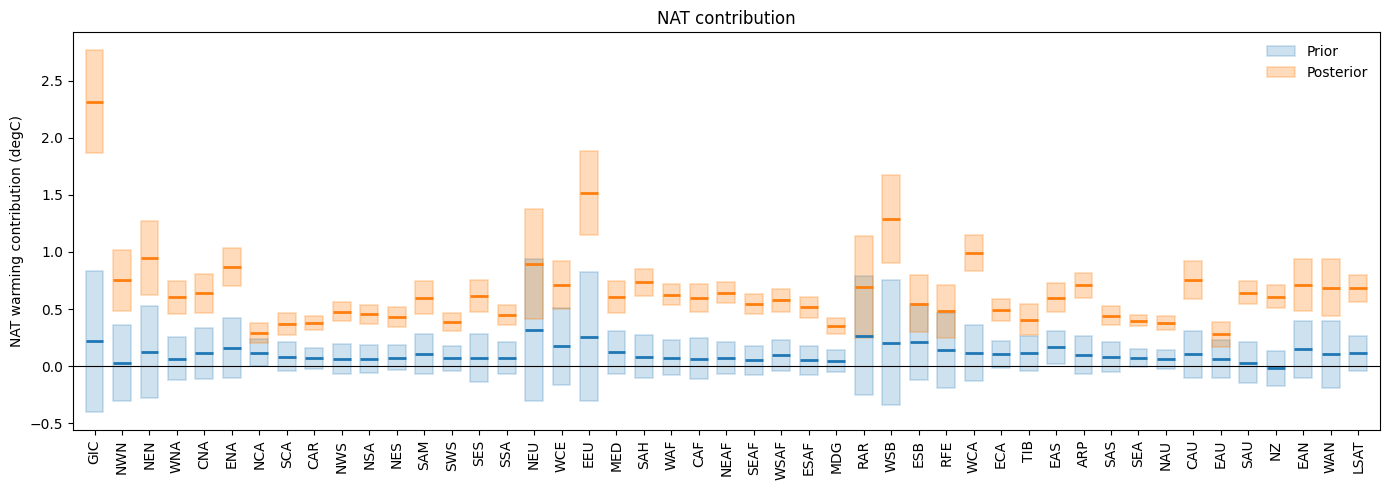

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

nat_prior = prior_warm_NATonly.sel(forcing="NAT")
nat_post = post_warm_NATonly.sel(forcing="NAT")

def plot_overlay_uncertainty_boxes(prior, post, title="NAT contribution"):
    x = np.arange(prior.sizes["region"])
    
    labels = (
        prior["abbrevs"].values
        if "abbrevs" in prior.coords
        else prior["region"].values
    )

    fig, ax = plt.subplots(figsize=(14, 5))

    box_width = 0.65

    for i in range(len(x)):
        # Prior
        p_mean = float(prior.isel(region=i).sel(quantile="mean"))
        p_low = float(prior.isel(region=i).sel(quantile="5th"))
        p_high = float(prior.isel(region=i).sel(quantile="95th"))

        ax.add_patch(Rectangle(
            (x[i] - box_width / 2, p_low),
            box_width,
            p_high - p_low,
            facecolor="tab:blue",
            edgecolor="tab:blue",
            alpha=0.22,
            linewidth=1.2,
            label="Prior" if i == 0 else None
        ))
        ax.hlines(p_mean, x[i] - box_width / 2, x[i] + box_width / 2,
                  color="tab:blue", linewidth=2)

        # Posterior, same x position, overlaid
        q_mean = float(post.isel(region=i).sel(quantile="mean"))
        q_low = float(post.isel(region=i).sel(quantile="5th"))
        q_high = float(post.isel(region=i).sel(quantile="95th"))

        ax.add_patch(Rectangle(
            (x[i] - box_width / 2, q_low),
            box_width,
            q_high - q_low,
            facecolor="tab:orange",
            edgecolor="tab:orange",
            alpha=0.28,
            linewidth=1.2,
            label="Posterior" if i == 0 else None
        ))
        ax.hlines(q_mean, x[i] - box_width / 2, x[i] + box_width / 2,
                  color="tab:orange", linewidth=2)

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=90)
    ax.set_ylabel("NAT warming contribution (degC)")
    ax.set_title(title)
    ax.legend(frameon=False)
    ax.margins(x=0.01)
    plt.tight_layout()
    return fig, ax

fig, ax = plot_overlay_uncertainty_boxes(nat_prior, nat_post)
plt.show()

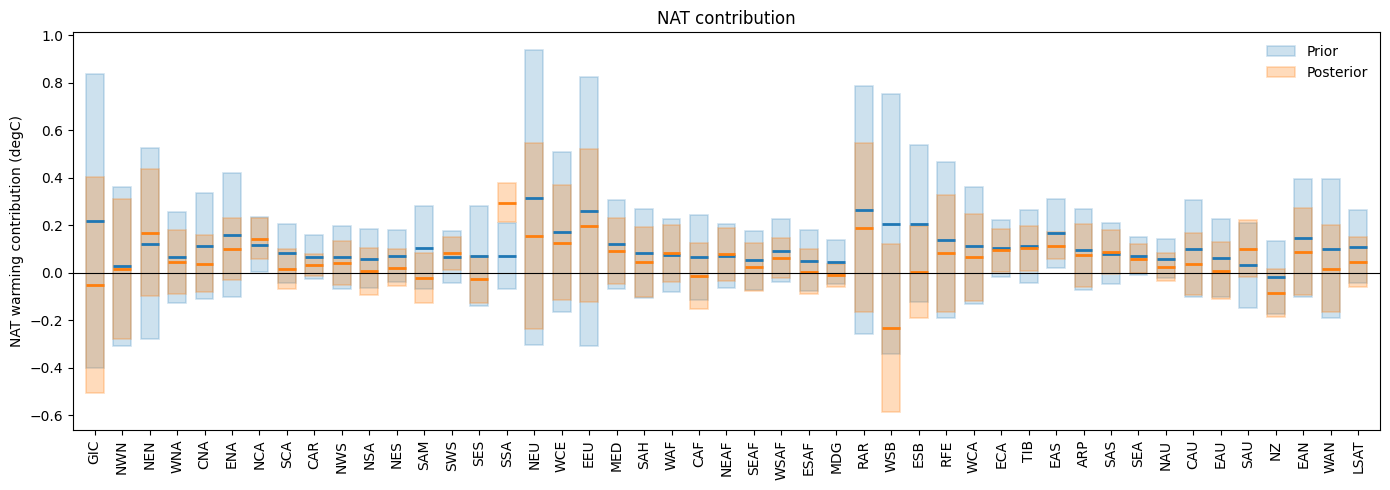

In [12]:
nat_prior = prior_warm_ANT_NAT.sel(forcing="NAT")
nat_post = post_warm_ANT_NAT.sel(forcing="NAT")

fig, ax = plot_overlay_uncertainty_boxes(nat_prior, nat_post)
plt.show()